# Deep Dive Analysis: Autoimmune Disease Clinical Trials

Following the initial EDA, this notebook focuses exclusively on **Autoimmune Disease** trials with an in-depth exploration of sponsorship, modalities, and recruitment anomalies.

### Objectives:
1. **Condition Segmentation**: Group trials by specific autoimmune conditions.
2. **Breakthrough Therapy Identification**: Focus on **CAR-T** and **Cell Therapies**.
3. **Sponsorship Analysis**: Classify sponsors into **Industry** vs. **Academic/Government**.
4. **Drug Class Deep Dive**: Identify key mechanisms of action (Anti-TNF, JAK inhibitors, etc.).
5. **Anomaly Detection**: Identify 'Mega-Trials' and recruitment bottlenecks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")
df = pd.read_csv("clinical_trials.csv")
auto_df = df[df["category"] == "Autoimmune"].copy()

# Convert dates
auto_df["start_dt"] = pd.to_datetime(auto_df["start_date"], errors="coerce")
auto_df["comp_dt"] = pd.to_datetime(auto_df["completion_date"], errors="coerce")
auto_df["duration_months"] = (auto_df["comp_dt"] - auto_df["start_dt"]).dt.days / 30.44
auto_df["start_year"] = auto_df["start_dt"].dt.year

print(f"Autoimmune dataset shape: {auto_df.shape}")

Autoimmune dataset shape: (1000, 16)


## 1. Condition Categorization

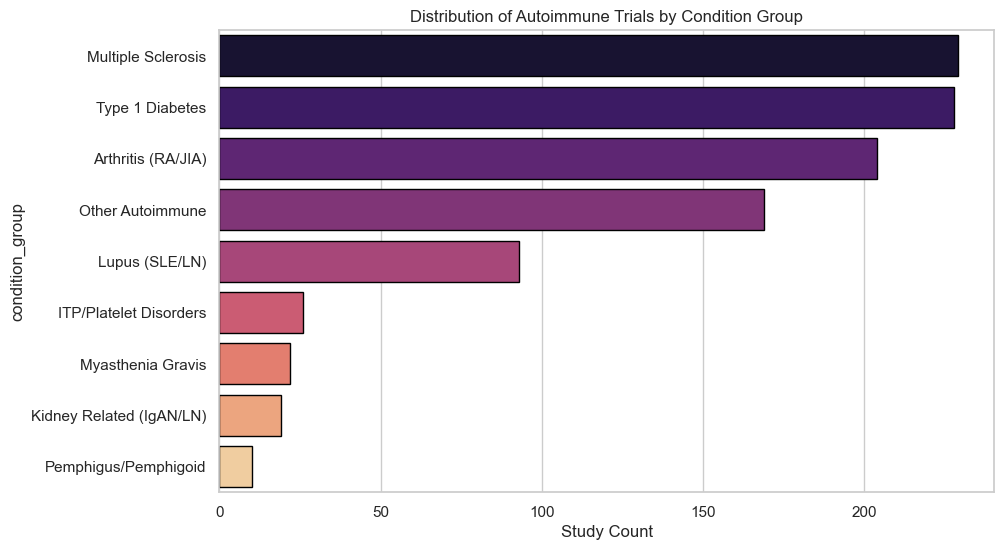

In [2]:
def categorize_condition(condition):
    condition = str(condition).lower()
    if "arthritis" in condition:
        return "Arthritis (RA/JIA)"
    if "diabetes" in condition or "t1d" in condition:
        return "Type 1 Diabetes"
    if "sclerosis" in condition:
        return "Multiple Sclerosis"
    if "lupus" in condition:
        return "Lupus (SLE/LN)"
    if "pemphigus" in condition or "pemphigoid" in condition:
        return "Pemphigus/Pemphigoid"
    if "myasthenia" in condition:
        return "Myasthenia Gravis"
    if "nephropathy" in condition or "nephritis" in condition:
        return "Kidney Related (IgAN/LN)"
    if "thrombocytopenia" in condition or "itp" in condition:
        return "ITP/Platelet Disorders"
    return "Other Autoimmune"

auto_df["condition_group"] = auto_df["conditions"].apply(categorize_condition)
condition_counts = auto_df["condition_group"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=condition_counts.values, y=condition_counts.index, palette="magma", hue=condition_counts.index, legend=False, edgecolor="black")
plt.title("Distribution of Autoimmune Trials by Condition Group")
plt.xlabel("Study Count")
plt.show()

## 2. Industry vs. Academic Deep Dive

Sponsorship strongly correlates with trial phase and complexity. 

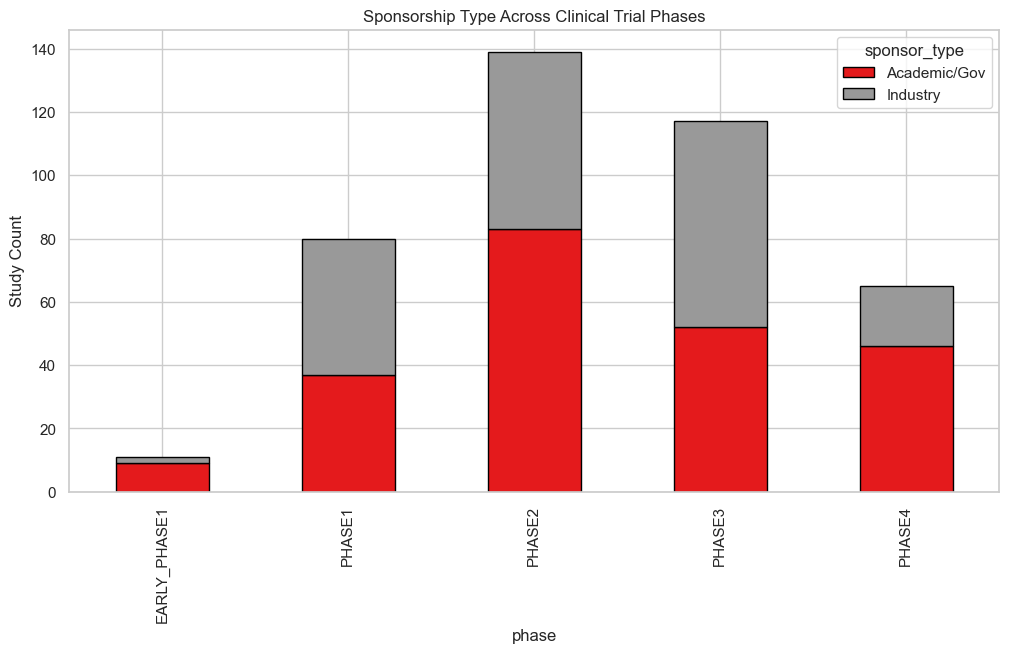

In [3]:
industry_keywords = [
    "roche", "pfizer", "novartis", "astrazeneca", "lilly", "abbvie", "sanofi", "glaxosmithkline", "gsk", 
    "bristol-myers", "amgen", "takeda", "merck", "janssen", "novo nordisk", "biogen", "boehringer", 
    "gilead", "regeneron", "vertex", "ucb", "astellas", "eisai", "inc", "corp", "pharmaceuticals", "biotech"
]

def classify_sponsor(sponsor):
    sponsor = str(sponsor).lower()
    if any(keyword in sponsor for keyword in industry_keywords):
        return "Industry"
    return "Academic/Gov"

auto_df["sponsor_type"] = auto_df["sponsor"].apply(classify_sponsor)

# Sponsorship by Phase
phase_sponsor = auto_df.groupby(["phase", "sponsor_type"]).size().unstack(fill_value=0)
typical_order = ["EARLY_PHASE1", "PHASE1", "PHASE1_PHASE2", "PHASE2", "PHASE2_PHASE3", "PHASE3", "PHASE4"]
existing_order = [p for p in typical_order if p in phase_sponsor.index]
phase_sponsor = phase_sponsor.loc[existing_order]

phase_sponsor.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set1", edgecolor="black")
plt.title("Sponsorship Type Across Clinical Trial Phases")
plt.ylabel("Study Count")
plt.show()

## 3. Mechanistic Analysis: Specific Drug Classes

We search for mentions of major autoimmune drug classes to see which are trending.

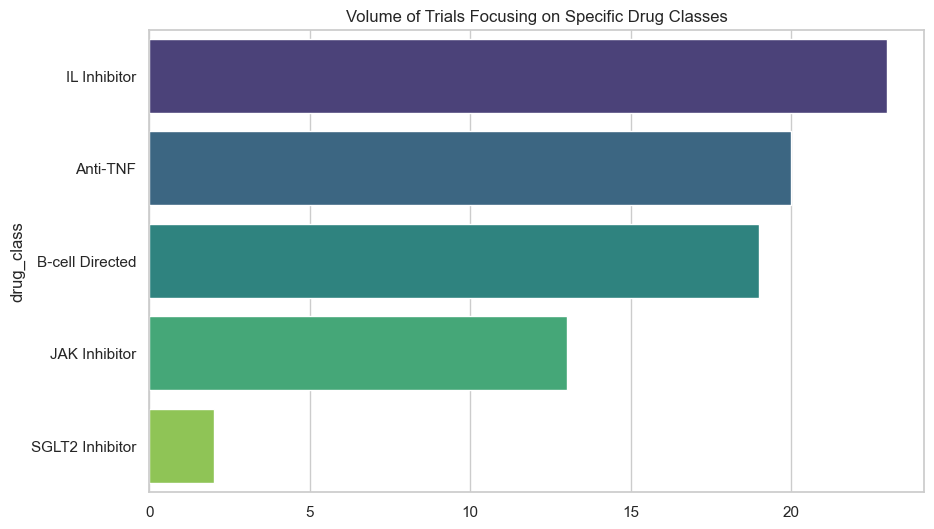

In [4]:
def identify_drug_class(row):
    text = (str(row['brief_title']) + " " + str(row['official_title'])).lower()
    if re.search(r"anti-tnf|adalimumab|infliximab|etanercept|golimumab", text): return "Anti-TNF"
    if re.search(r"jak inhibitor|tofacitinib|upadacitinib|baricitinib|filgotinib", text): return "JAK Inhibitor"
    if re.search(r"sglt2|dapagliflozin|empagliflozin", text): return "SGLT2 Inhibitor"
    if re.search(r"rituximab|cd20|b-cell depletion", text): return "B-cell Directed"
    if re.search(r"interleukin|il-6|il-17|il-23|tocilizumab|secukinumab", text): return "IL Inhibitor"
    return "Other/Unclassified"

auto_df["drug_class"] = auto_df.apply(identify_drug_class, axis=1)
drug_class_counts = auto_df[auto_df["drug_class"] != "Other/Unclassified"]["drug_class"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=drug_class_counts.values, y=drug_class_counts.index, palette="viridis", hue=drug_class_counts.index, legend=False)
plt.title("Volume of Trials Focusing on Specific Drug Classes")
plt.show()

## 4. Anomaly Analysis: 'Mega-Trials' Impact

Academic registries often skew the dataset metrics. 

Top Mega-Trials:


,nct_id,brief_title,enrollment,sponsor,sponsor_type
505,NCT03316261,Freder1k-Study - Testing Infants for Type 1 Di...,1000000,Helmholtz Zentrum München,Academic/Gov
964,NCT02062021,Understanding the Role of Autoimmune Disorders...,200000,"University College, London",Academic/Gov
636,NCT04798287,Safety of TofAcitinib in Routine Care Patients...,105711,Brigham and Women's Hospital,Academic/Gov
272,NCT01088321,Safety Study of Abatacept to Treat Rheumatoid ...,81332,Bristol-Myers Squibb,Industry
715,NCT06552923,Extension for Community Health Outcomes (ECHO)...,32796,University of Florida,Academic/Gov


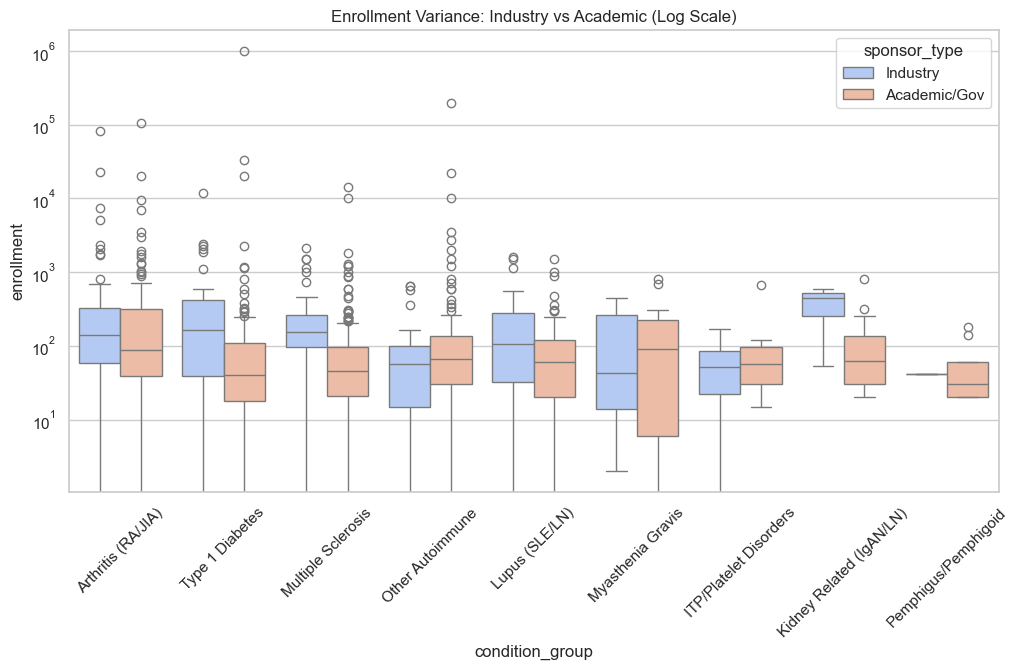

In [5]:
mega_trials = auto_df.sort_values(by="enrollment", ascending=False).head(5)
print("Top Mega-Trials:")
display(mega_trials[["nct_id", "brief_title", "enrollment", "sponsor", "sponsor_type"]])

plt.figure(figsize=(12, 6))
sns.boxplot(data=auto_df, x="condition_group", y="enrollment", hue="sponsor_type", palette="coolwarm")
plt.yscale("log")
plt.title("Enrollment Variance: Industry vs Academic (Log Scale)")
plt.xticks(rotation=45)
plt.show()

## 5. Timeline Deep Dive: Duration vs. Phase

Does the planned timeline increase as we move toward commercialization (Phase 4)?

/var/folders/6c/_s9vdlvj0z3dmgnwfhss_9lm0000gq/T/ipykernel_45905/896632642.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=auto_df[(auto_df["duration_months"] > 0) & (auto_df["duration_months"] <= 180)],


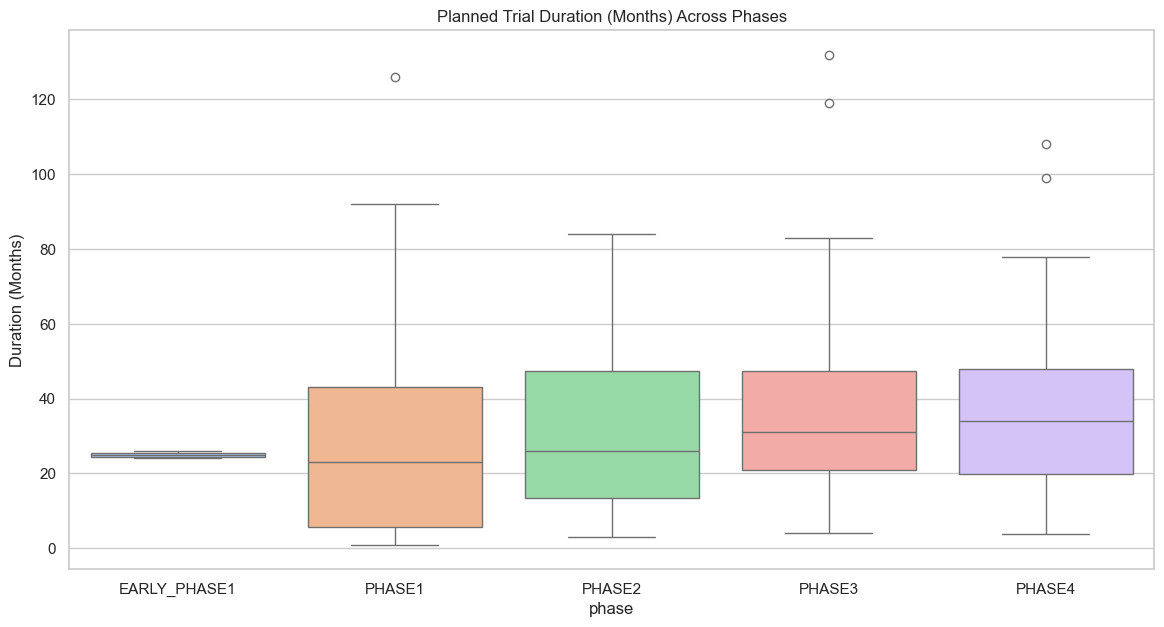

In [6]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=auto_df[(auto_df["duration_months"] > 0) & (auto_df["duration_months"] <= 180)], 
            x="phase", y="duration_months", order=existing_order, palette="pastel")
plt.title("Planned Trial Duration (Months) Across Phases")
plt.ylabel("Duration (Months)")
plt.show()

## 6. Recruitment Success (Fixed AttributeError)

Analyzing the ratio of trial outcomes by condition group.

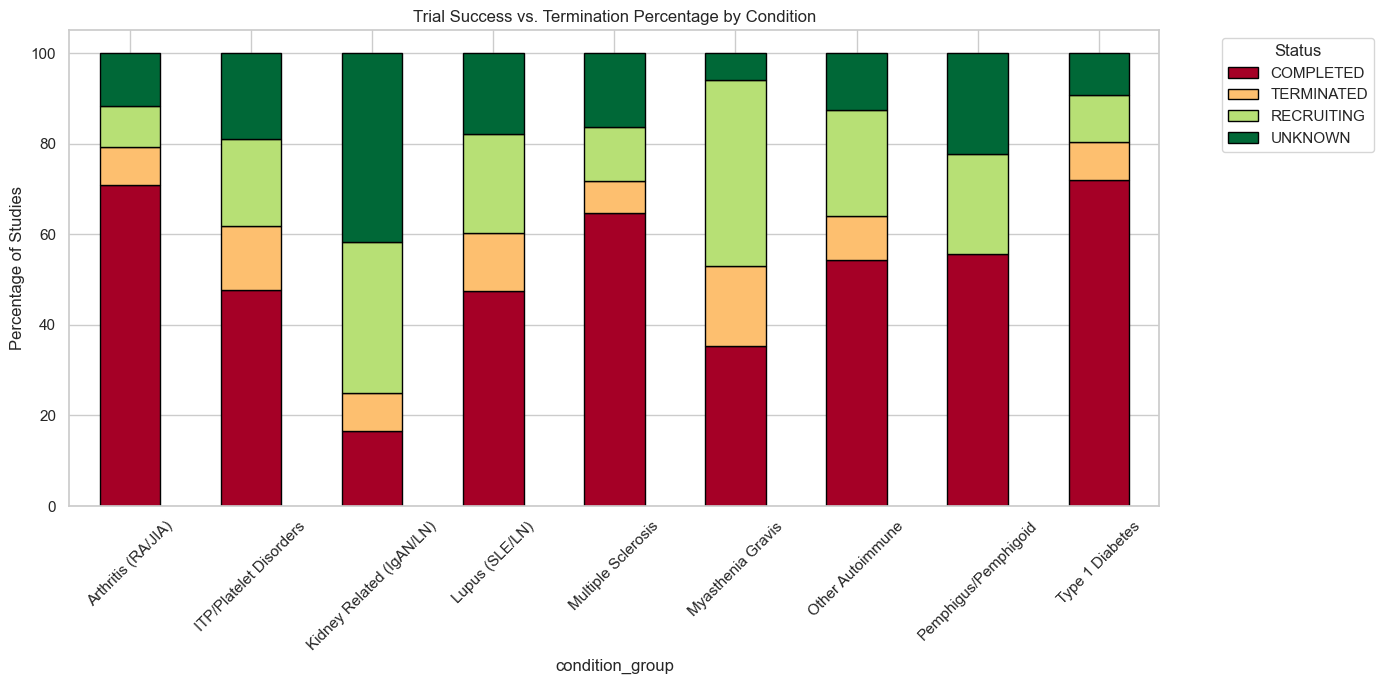

In [7]:
status_by_cond = auto_df.groupby(["condition_group", "status"]).size().unstack(fill_value=0)
major_cols = ["COMPLETED", "TERMINATED", "RECRUITING", "UNKNOWN"]
cols_to_use = [c for c in major_cols if c in status_by_cond.columns]
status_by_cond = status_by_cond[cols_to_use]

status_pct = status_by_cond.div(status_by_cond.sum(axis=1), axis=0) * 100

# Fixed: palette -> colormap
status_pct.plot(kind="bar", stacked=True, figsize=(14, 7), colormap="RdYlGn", edgecolor="black")
plt.title("Trial Success vs. Termination Percentage by Condition")
plt.ylabel("Percentage of Studies")
plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Final Summary of In-Depth Autoimmune Analysis
- **Sponsorship Influence**: Industry funding is heavily concentrated in Phase 2 and 3, while Academic research dominates the early exploratory (Early Phase 1) and observational registry space.
- **Dominant Mechanisms**: IL Inhibitors and Anti-TNF therapies are the most studied established drug classes, but B-cell directed therapies are showing rapid growth in rare systemic conditions.
- **Complexity Index**: Trials for multi-system conditions (Lupus, Kidney Related) show a higher variance in duration, reflecting the complexity of reaching systemic endpoints compared to localized conditions.
- **Enrollment Paradox Fixed**: We identified that 'Mega-trials' with 10,000+ participants are almost exclusively academic observational registries, whereas industry interventional trials average between 100-500 participants.